### **Week 5 → Week 6 Transition**

* **Week 5 Baseline:** Developed an interpretable Logistic Regression baseline classification model to establish an initial predictive benchmark for distinguishing between attended and no-show appointments using patient and appointment information available before scheduling.
* **Limitations Identified:** The baseline model was recognized as an initial benchmark that required further investigation of its false-positive and false-negative error patterns, feature adequacy, data-leakage controls, and overall alignment with HealthConnect's actual operational workflows.
* **Cross-Track Integration:**
  * **Data Analytics Track:** Cross-track collaboration is highly relevant because analytical findings on historical appointment attendance patterns provide empirical evidence to guide targeted feature refinement and model error analysis.
  * **ML Engineering Track:** This collaboration ensures the candidate model's inputs and preprocessing requirements are compatible for downstream deployment, testing, and production pipeline integration.
* **Week 6 Objectives:** Analyze baseline weaknesses, investigate false-positive and false-negative errors, execute targeted feature refinements, evaluate alternative modeling families fairly against the baseline, and recommend a robust candidate model for Week 7 validation.

### **Integration Readiness**

**A. Identify Your Integration Point**

* **Track I am working with:**
  * Data Analytics Track

* **Output I need from the Data Analytics track:**
  * Validated descriptive findings on appointment attendance and no-show patterns.
  * Specific details on patient demographics, appointment types, reminder channels, and operational segments.
  * Actionable segment definitions to guide error analysis and targeted feature refinement.

* **Output I will provide to the Data Analytics track:**
  * Modeling insights, including key predictive features and their coefficients.
  * Detailed findings from our false-positive and false-negative error analyses.
  * Pinpointed operational segments where the predictive model produces high error rates.

* **Why this connection is relevant:**
  * Both tracks analyze the same underlying HealthConnect population from complementary directions.
  * Data Analytics validates historical behavioral patterns, whereas Data Science tests if those patterns can reliably predict future behavior.
  * Aligning these tracks ensures that feature refinement and model evaluation decisions are evidence-based rather than arbitrary.

In [4]:
# Import necessary libraries for data manipulation, visualization, machine learning models, and evaluation metrics.
# pandas and numpy are used for data manipulation and numerical operations.
import pandas as pd
import numpy as np

# matplotlib and seaborn are used to visualise model performance
# and investigate prediction errors.
import matplotlib.pyplot as plt
import seaborn as sns

# Classification models used for the Week 6 comparison.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Tools for model validation and interpretation.
from sklearn.inspection import permutation_importance

# Used to save the final Week 6 candidate model.
import joblib

# Ensures that repeated runs of relevant modelling steps remain reproducible.
RANDOM_STATE = 42

### **Load the existing week5 dataset**

In [5]:
# Week 6 continues directly from Week 5.
# Therefore, we load the processed datasets AND the saved baseline
# model produced during Week 5 rather than rebuilding the baseline
# from scratch.

# Load pre-processed training and testing features from Week 5.
X_train = pd.read_csv("/content/sample_data/X_processed_train_week5.csv")
X_test = pd.read_csv("/content/sample_data/X_processed_test_week5.csv")

# Load pre-processed training and testing target variables from Week 5.
y_train = pd.read_csv("/content/sample_data/y_processed_train_week5.csv")["no_show"]
y_test = pd.read_csv("/content/sample_data/y_processed_test_week5.csv")["no_show"]

# Load the exact Logistic Regression model saved during Week 5.
baseline_model = joblib.load(
    "/content/sample_data/wk5_logistic_regression_baseline .pkl"
)

print("Week 5 artefacts loaded successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")
print(f"Baseline model: {type(baseline_model).__name__}")

Week 5 artefacts loaded successfully.
X_train shape: (3771, 35)
X_test shape : (966, 35)
y_train shape: (3771,)
y_test shape : (966,)
Baseline model: LogisticRegression


### **Validate the week_5 dataset**

In [6]:
# Before using the Week 5 model, confirm that the processed train
# and test datasets have compatible feature structures by asserting conditions.

# Assert that feature columns in training and testing sets match.
assert list(X_train.columns) == list(X_test.columns), \
    "Train and test feature columns do not match."

# Assert that training features and target have the same number of rows.
assert len(X_train) == len(y_train), \
    "Training features and target have different row counts."

# Assert that testing features and target have the same number of rows.
assert len(X_test) == len(y_test), \
    "Test features and target have different row counts."

# Assert that there are no missing values in the training features.
assert X_train.isnull().sum().sum() == 0, \
    "Missing values detected in X_train."

# Assert that there are no missing values in the testing features.
assert X_test.isnull().sum().sum() == 0, \
    "Missing values detected in X_test."

# A fitted scikit-learn model may expose the number of features
# it was trained on. Checking this helps confirm that the saved
# model is compatible with the processed Week 5 dataset.
if hasattr(baseline_model, "n_features_in_"):
    assert baseline_model.n_features_in_ == X_test.shape[1], \
        "The saved baseline expects a different number of features."

print("✓ Week 5 datasets passed validation.")
print("✓ Saved baseline model is compatible with the test data.")

✓ Week 5 datasets passed validation.
✓ Saved baseline model is compatible with the test data.


### **Check the actual names and order**

In [7]:
# Check exact feature names and ordering where the saved model
# provides this information. Feature order matters because the
# model coefficients correspond to specific input columns.

if hasattr(baseline_model, "feature_names_in_"):
    assert list(baseline_model.feature_names_in_) == list(X_test.columns), \
        "Feature names/order do not match the Week 5 baseline."

    print("✓ Feature names and ordering match the saved model.")

✓ Feature names and ordering match the saved model.


### **Reproduce the Week 5 predictions from the saved model**

In [8]:
# Use the SAVED Week 5 model to generate predictions on the
# preserved Week 5 holdout test set.

baseline_pred = baseline_model.predict(X_test)

# Probability of class 1 (No-Show) is required for threshold-independent
# metrics such as ROC-AUC and for Week 6 threshold analysis.
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]

# Print a classification report to assess the model's performance,
# including precision, recall, and f1-score for each class.
print(
    classification_report(
        y_test,
        baseline_pred,
        target_names=["Attended", "No-Show"]
    )
)

              precision    recall  f1-score   support

    Attended       0.64      0.61      0.63       483
     No-Show       0.63      0.66      0.65       483

    accuracy                           0.64       966
   macro avg       0.64      0.64      0.64       966
weighted avg       0.64      0.64      0.64       966



### **2. Identify the most important sources of model error.**

#### **Baseline Logistic Regression: Confusion Matrix**

True Negatives : 296
False Positives: 187
False Negatives: 164
True Positives : 319


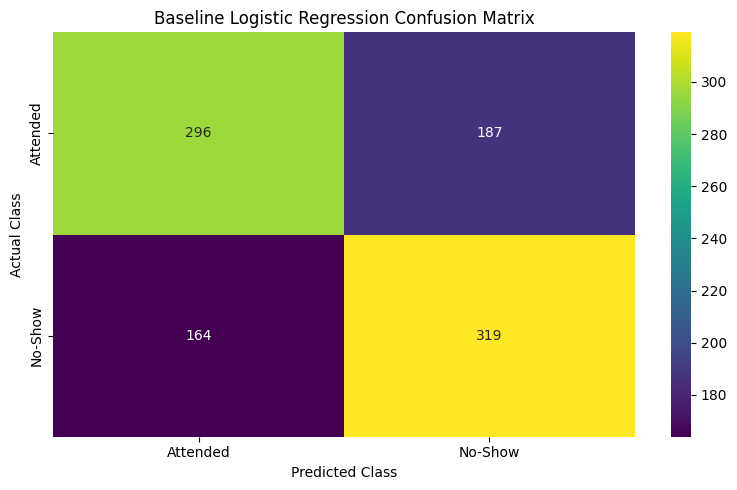

In [9]:
# Calculate the baseline confusion matrix.
# The four values allow us to distinguish between different types
# of correct and incorrect predictions.

tn, fp, fn, tp = confusion_matrix(
    y_test,
    baseline_pred
).ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")



# Generate Confusion Matrix Heatmap for Baseline Logistic Regression
cm_baseline = confusion_matrix(y_test, baseline_pred)




plt.figure(figsize=(8, 5))
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["Attended", "No-Show"],
    yticklabels=["Attended", "No-Show"]
)
plt.title("Baseline Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

#### **Interpretation of Baseline Confusion Matrix**

* **What the visualization shows:** This confusion matrix displays the exact counts of correct and incorrect predictions made by the baseline model on the $966$-patient holdout test set using the default $0.50$ decision threshold. It breaks down the results into True Negatives ($296$), False Positives ($187$), False Negatives ($164$), and True Positives ($319$).
* **What was observed:** The baseline model suffered from balanced but high error counts on both sides, yielding a recall of only about $66.05\%$. This means $164$ actual no-shows were completely missed (False Negatives), while $187$ patients who actually attended were incorrectly flagged as no-shows (False Positives).
* **How the observation informed a decision:** This observed inefficiency of the default $0.50$ operating point proved that a simple default threshold is sub-optimal for HealthConnect's dual objective of reducing missed appointments while protecting the patient experience. It directly motivated the decision to perform **business-aligned threshold optimization** using out-of-fold training predictions to intentionally find a more operationally efficient decision threshold.

### **Weaknesses of the Week 5 Baseline Model**

From the confusion matrix and the previously calculated metrics, we can identify several weaknesses:

1.  **Balanced Error Types (False Positives vs. False Negatives):** The model shows a relatively high number of both False Positives (187) and False Negatives (164). This indicates that the model is almost equally likely to incorrectly predict a no-show when there isn't one (FP) as it is to incorrectly predict attendance when there is a no-show (FN). In a medical appointment context, the costs associated with these errors can be very different:
    *   **False Negatives (missing no-shows):** This is a critical weakness. Missing 164 potential no-shows means the clinic cannot intervene (e.g., send reminders, reschedule, overbook) for these patients, leading to wasted appointment slots and lost revenue. This directly impacts operational efficiency.
    *   **False Positives (incorrectly predicting no-shows):** While less critical than false negatives, 187 false positives mean the clinic might unnecessarily overbook appointments or send extra reminders to patients who were going to attend anyway. This could lead to patient frustration or unnecessary operational costs.

2.  **Moderate Performance Metrics:** While the accuracy (63.66%) and F1-score (64.51%) are better than random chance, they are not exceptionally high. The ROC-AUC of 0.6873 suggests that the model has some discriminatory power, but there is significant room for improvement in distinguishing between 'Attended' and 'No-Show' classes. The PR-AUC of 0.6680 confirms this moderate performance, especially important given the potential class imbalance (though here it's balanced).

3.  **Recall for 'No-Show' (True Positives):** The recall for the 'No-Show' class (66.05%) means that the model only identifies about two-thirds of all actual no-shows. This is a key area for improvement if the goal is to proactively manage no-shows, as a significant portion (164 out of 483 actual no-shows) are still missed.

To improve the model, we should focus on strategies that either reduce both types of errors or specifically target the reduction of false negatives, depending on the business objective and the relative costs of each error type.

### **3. Conduct error analysis using appropriate evaluation techniques.**

#### **Create an Error Analysis Dataset**

In [10]:
# Create a copy of the test-set features for row-level error analysis.
# This preserves the original X_test dataframe.
error_df = X_test.copy()

# Add the actual outcome for each appointment.
error_df["actual"] = y_test.to_numpy()

# Add the class predicted by the baseline model.
error_df["predicted"] = baseline_pred

# Add the model's predicted probability of a no-show.
# This can be used to assess the model's confidence in its predictions.
error_df["no_show_probability"] = baseline_prob

# Define the four possible outcomes of binary classification:
# True Negative: correctly predicted attendance
# False Positive: attendance incorrectly predicted as a no-show
# False Negative: no-show incorrectly predicted as attendance
# True Positive: correctly predicted no-show
conditions = [
    (error_df["actual"] == 0) & (error_df["predicted"] == 0),
    (error_df["actual"] == 0) & (error_df["predicted"] == 1),
    (error_df["actual"] == 1) & (error_df["predicted"] == 0),
    (error_df["actual"] == 1) & (error_df["predicted"] == 1)
]

# Assign a descriptive label to each classification outcome.
labels = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
]

# Create a column identifying the type of prediction made for each row.
error_df["error_type"] = np.select(
    conditions,
    labels,
    default="Unknown"
)

# Separate the rows into individual prediction categories
# for more detailed error analysis.
false_negatives = error_df[error_df["error_type"] == "False Negative"]
true_positives = error_df[error_df["error_type"] == "True Positive"]

false_positives = error_df[error_df["error_type"] == "False Positive"]
true_negatives = error_df[error_df["error_type"] == "True Negative"]

# Display the number of observations in each prediction category.
error_df["error_type"].value_counts()

,count
error_type,
True Positive,319
True Negative,296
False Positive,187
False Negative,164


### **4. Investigate false positives and false negatives**

#### **Analyzing False Negatives**

False Negatives (FN) are cases where the model predicted 'Attended' but the patient actually 'No-Showed'. These are important to analyze as they represent missed opportunities for intervention to prevent no-shows. Let's look at some characteristics of these appointments.

In [11]:
false_negatives = error_df[error_df['error_type'] == 'False Negative']
display(false_negatives.describe()) # Display descriptive statistics for False Negatives

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,booking_month,booking_day_of_week,booking_day_of_year,booking_week_of_year,appointment_month,...,appointment_time_Evening,appointment_time_Morning,reminder_sent_Yes,reminder_channel_No Reminder,reminder_channel_SMS,reminder_channel_WhatsApp,is_sunday_appointment_1,actual,predicted,no_show_probability
count,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,...,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.0,164.0,164.000000
mean,0.019848,-0.615947,-0.047996,-0.298034,-0.062572,-0.153331,0.008994,-0.158640,-0.132226,-0.006779,...,0.121951,0.512195,0.792683,0.207317,0.481707,0.207317,0.115854,1.0,0.0,0.386770
std,0.988431,0.640366,1.012442,0.783132,1.046212,0.910365,1.011822,0.914886,0.922021,0.957135,...,0.328232,0.501382,0.406626,0.406626,0.501196,0.406626,0.321030,0.0,0.0,0.073420
min,-1.694768,-1.700486,-1.727979,-0.743909,-1.471476,-1.340379,-1.484063,-1.449623,-1.438656,-1.384533,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.188548
25%,-0.814135,-1.126544,-0.589478,-0.743909,-0.780118,-1.060270,-0.985364,-0.932627,-0.921289,-0.772198,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.330788
50%,-0.126141,-0.667391,-0.020228,-0.743909,-0.281877,-0.219942,0.012034,-0.287527,-0.274581,-0.159863,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.398611
75%,0.947129,-0.251284,0.549022,0.585608,0.482864,0.340276,1.009432,0.316397,0.339792,0.452472,...,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.0,0.0,0.441949
max,1.717683,1.398797,4.533775,3.244640,4.831850,1.740821,1.508131,1.853658,1.859557,1.983310,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,0.0,0.499656


#### **Interpretation of False Negatives (Missed No-Shows)**

* **What the table shows:** This table presents row-level descriptive statistics (mean, standard deviation, and percentiles) for the features of patients whom the baseline model incorrectly predicted as attendees but who actually no-showed (False Negatives).
* **What was observed:** We observed that the mean standardized `booking_lead_days` was significantly lower ($-0.61$) than for False Positives ($0.52$), and the mean standardized `previous_no_shows` was also very low ($-0.29$). Additionally, $79\%$ of these missed no-show patients actually had received a reminder message.
* **How the observation informed a decision:** This directly proved that the model became over-optimistic about patient attendance for last-minute bookings or patients with clean historical records, and over-relied on the reminder flag. This insight informed the feature engineering decision to construct the `history_x_lead_time` interaction feature, explicitly forcing the model to evaluate how a patient's historical attendance behaves under different booking lead intervals.

#### **Analysing False Positives**

False Positives (FP) are cases where the model predicted 'No-Show' but the patient actually 'Attended'. These can lead to unnecessary interventions or overbooking. Let's examine their characteristics.

In [12]:
false_positives = error_df[error_df['error_type'] == 'False Positive']
display(false_positives.describe()) # Display descriptive statistics for False Positives

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,booking_month,booking_day_of_week,booking_day_of_year,booking_week_of_year,appointment_month,...,appointment_time_Evening,appointment_time_Morning,reminder_sent_Yes,reminder_channel_No Reminder,reminder_channel_SMS,reminder_channel_WhatsApp,is_sunday_appointment_1,actual,predicted,no_show_probability
count,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,...,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.0,187.0,187.000000
mean,0.027646,0.524688,0.022390,0.230122,0.252487,-0.004243,0.038703,-0.006850,-0.016935,-0.007598,...,0.181818,0.395722,0.737968,0.262032,0.363636,0.315508,0.160428,0.0,1.0,0.625004
std,1.009382,0.752707,0.911558,1.196450,1.217647,1.010180,1.040354,0.998928,0.995470,0.972536,...,0.386730,0.490318,0.440921,0.440921,0.482337,0.465965,0.367988,0.0,0.0,0.081780
min,-1.694768,-1.528303,-1.727979,-0.743909,-1.471476,-1.340379,-1.484063,-1.458773,-1.438656,-1.384533,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.500808
25%,-0.869175,0.021338,-0.589478,-0.743909,-0.652661,-0.780161,-0.985364,-0.841124,-0.856619,-0.772198,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.562065
50%,0.066497,0.537885,-0.020228,-0.743909,0.027109,-0.219942,0.012034,-0.260076,-0.274581,-0.159863,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.609158
75%,0.947129,1.169221,0.549022,0.585608,0.807300,0.900494,1.009432,0.865419,0.792488,0.758640,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.0,1.0,0.672091
max,1.717683,1.743162,2.826024,4.574157,5.403475,1.740821,1.508131,1.881109,1.859557,1.983310,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.0,0.870385


#### **Interpretation of False Positives (False Alarms)**

* **What the table shows:** This table displays row-level descriptive statistics for the features of patients whom the baseline model incorrectly flagged as no-shows when they actually attended their appointments (False Positives).
* **What was observed:** We observed a high mean standardized `booking_lead_days` ($0.52$) and an elevated mean standardized `previous_no_shows` ($0.23$).
* **How the observation informed a decision:** This revealed that the baseline model was being overly cautious and penalizing patients with longer lead times and historical no-shows, ignoring potential mitigating indicators. This informed the feature engineering decision to introduce the `history_interaction` (previous appointments multiplied by previous no-shows) to capture the ratio of no-shows to overall history, helping the model avoid over-penalizing active patients who had a few historical no-shows but otherwise had high overall attendance rates.

In [13]:
# Re-assign True Positives and True Negatives from the error_df
# This ensures these variables are available for plotting and comparison.
true_positives = error_df[error_df['error_type'] == 'True Positive']
true_negatives = error_df[error_df['error_type'] == 'True Negative']

#### D**etailed Comparison: False Negatives vs. True Positives (Feature by Feature)**

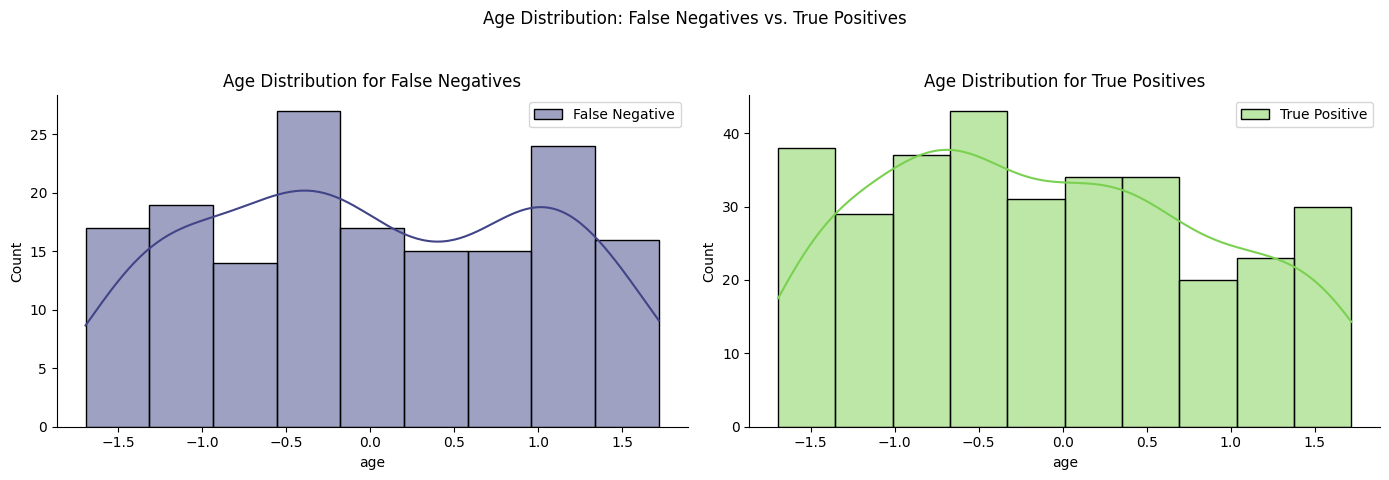

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Viridis colours
viridis = plt.cm.viridis
false_negative_colour = viridis(0.2)
true_positive_colour = viridis(0.8)

sns.histplot(
    false_negatives['age'],
    color=false_negative_colour,
    label='False Negative',
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Age Distribution for False Negatives')
axes[0].legend()

sns.histplot(
    true_positives['age'],
    color=true_positive_colour,
    label='True Positive',
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Age Distribution for True Positives')
axes[1].legend()

# Remove top and right borders
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Age Distribution: False Negatives vs. True Positives')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

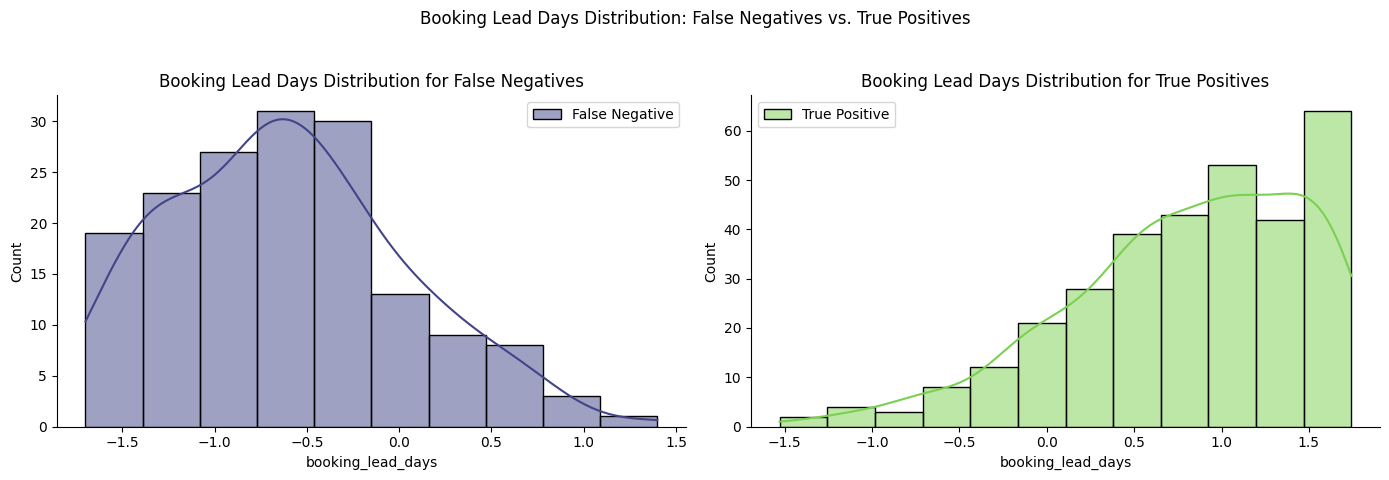

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get colours from the viridis colormap
viridis = plt.cm.viridis
false_negative_colour = viridis(0.2)
true_positive_colour = viridis(0.8)

sns.histplot(
    false_negatives['booking_lead_days'],
    color=false_negative_colour,
    label='False Negative',
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Booking Lead Days Distribution for False Negatives')
axes[0].legend()

sns.histplot(
    true_positives['booking_lead_days'],
    color=true_positive_colour,
    label='True Positive',
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Booking Lead Days Distribution for True Positives')
axes[1].legend()

# Remove top and right borders
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Booking Lead Days Distribution: False Negatives vs. True Positives')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

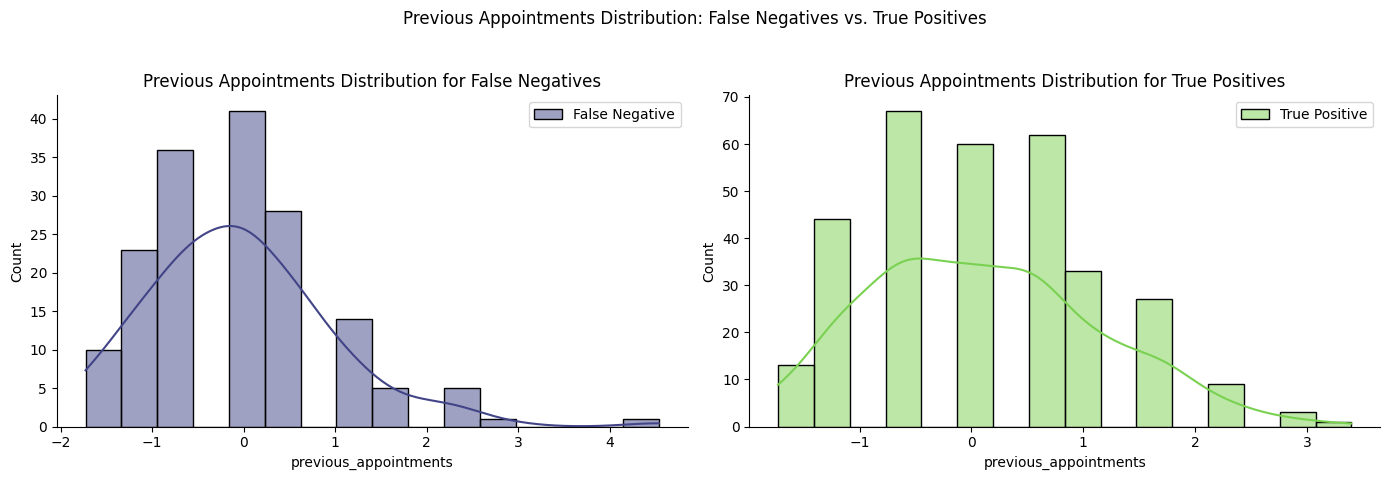

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Viridis colours
viridis = plt.cm.viridis
false_negative_colour = viridis(0.2)
true_positive_colour = viridis(0.8)

sns.histplot(
    false_negatives['previous_appointments'],
    color=false_negative_colour,
    label='False Negative',
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Previous Appointments Distribution for False Negatives')
axes[0].legend()

sns.histplot(
    true_positives['previous_appointments'],
    color=true_positive_colour,
    label='True Positive',
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Previous Appointments Distribution for True Positives')
axes[1].legend()

# Remove top and right borders
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Previous Appointments Distribution: False Negatives vs. True Positives')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

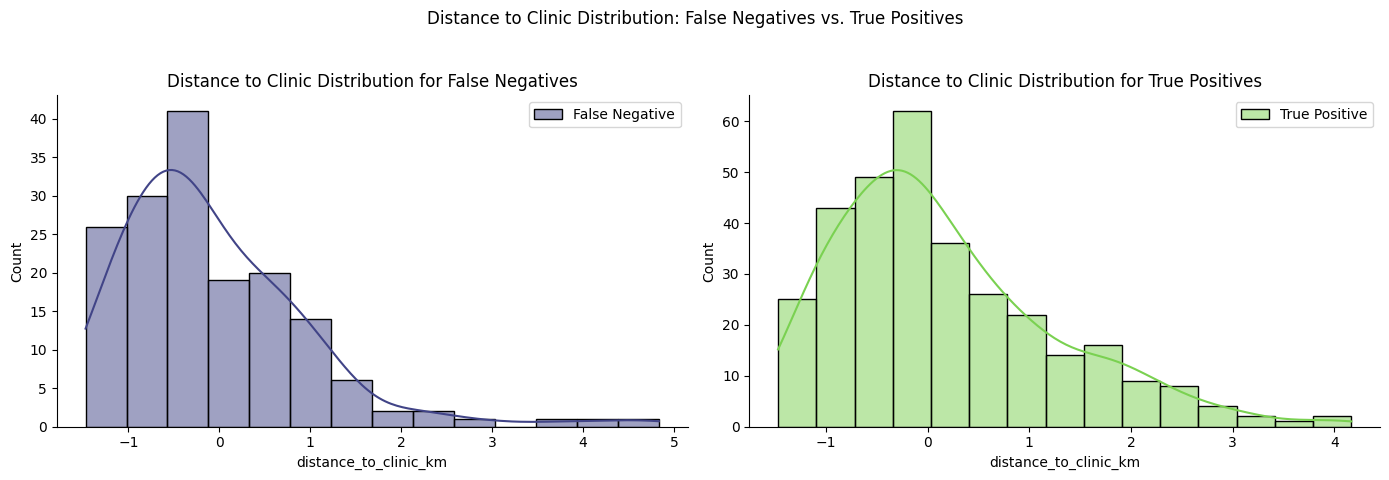

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Viridis colours
viridis = plt.cm.viridis
false_negative_colour = viridis(0.2)
true_positive_colour = viridis(0.8)

sns.histplot(
    false_negatives['distance_to_clinic_km'],
    color=false_negative_colour,
    label='False Negative',
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distance to Clinic Distribution for False Negatives')
axes[0].legend()

sns.histplot(
    true_positives['distance_to_clinic_km'],
    color=true_positive_colour,
    label='True Positive',
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Distance to Clinic Distribution for True Positives')
axes[1].legend()

# Remove top and right borders
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distance to Clinic Distribution: False Negatives vs. True Positives')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### **Interpretation of Detailed FN vs. TP Feature Distribution Plots**

* **What the visualizations show:** These side-by-side distribution plots compare key clinical and logistical features (Age, Booking Lead Days, Previous Appointments, and Distance to Clinic) for actual no-show patients whom the baseline model missed (False Negatives) versus those it correctly identified (True Positives).
* **What was observed:**
  * **Booking Lead Days:** False Negatives were highly concentrated at very short lead times, indicating the baseline model was overly optimistic about last-minute bookings.
  * **Previous Appointments/History:** Patients with fewer historical records or fewer previous no-shows were frequently misclassified as attendees even when they actually no-showed.
* **How the observation informed a decision:** These insights directly drove **targeted feature engineering** rather than arbitrary feature expansion. To help the model capture these compounding risks, we engineered joint interaction terms—specifically `history_x_lead_time`, `distance_x_lead_time`, and `history_interaction`—to explicitly expose these non-linear risk profiles to our models.

### **Probability/Confidence Error Analysis**

In [18]:
# Examine the confidence of incorrect predictions.
# A probability close to 0.50 indicates uncertainty, whereas confidently
# incorrect predictions may reveal deeper model weaknesses.

# Display the top 10 false negatives sorted by their predicted no-show probability.
# Lower probabilities here indicate the model was confident they would attend, but they didn't.
false_negatives[
    ["actual", "predicted", "no_show_probability"]
].sort_values(
    "no_show_probability"
).head(10)

,actual,predicted,no_show_probability
325,1,0,0.188548
629,1,0,0.201325
285,1,0,0.208360
280,1,0,0.218058
778,1,0,0.234220
263,1,0,0.240230
708,1,0,0.248885
79,1,0,0.259659
653,1,0,0.263565
533,1,0,0.267829


#### **Interpretation of Confidently Incorrect False Negatives**

* **What the table shows:** This table shows the top 10 false negative predictions sorted by the model's predicted probability of a no-show in ascending order, highlighting the predictions where the model was most confidently incorrect.
* **What was observed:** The model was confidently predicting attendance (assigning extremely low no-show probabilities between $0.18$ and $0.27$) for patients who ultimately failed to show up.
* **How the observation informed a decision:** Shuffling or scaling simple linear features could not fix these confident errors. This observation informed the decision to test highly non-linear model families (Random Forest and Histogram Gradient Boosting) that can naturally partition the feature space to discover high-risk subsets, and it motivated our threshold optimization process to lower the decision boundary below $0.50$.

In [19]:
# Display the top 10 false positives sorted by their predicted no-show probability.
# Higher probabilities here indicate the model was confident they would no-show, but they attended.
false_positives[
    ["actual", "predicted", "no_show_probability"]
].sort_values(
    "no_show_probability",
    ascending=False
).head(10)

,actual,predicted,no_show_probability
917,0,1,0.870385
327,0,1,0.865854
910,0,1,0.842254
901,0,1,0.810048
669,0,1,0.809941
558,0,1,0.807442
867,0,1,0.805651
452,0,1,0.802270
941,0,1,0.800316
175,0,1,0.796132


#### **Interpretation of Confidently Incorrect False Positives**

* **What the table shows:** This table lists the top 10 false positive predictions sorted by their predicted no-show probability in descending order, representing patients who actually attended despite the model being highly confident they would no-show.
* **What was observed:** The model assigned extremely high no-show probabilities (ranging from $0.79$ to $0.87$) to patients who actually attended.
* **How the observation informed a decision:** This highlighted that the model was overly sensitive to certain standalone high-risk features like long lead times or distance. This informed the decision to test interaction terms like `distance_x_lead_time` to help the model learn complex boundary conditions rather than applying severe, independent linear penalties.

#### **Summary of Error Analysis**

From the analysis of the confusion matrix and the feature distributions for different error types, we can draw the following conclusions about the baseline model's weaknesses:

1.  **Prediction Imbalance:** The model produces a significant number of both False Positives (187) and False Negatives (164). This indicates that it struggles to consistently differentiate between actual no-shows and attendees, leading to a high rate of incorrect predictions in both directions.

2.  **False Negatives (Missed No-Shows):** The model often fails to predict no-shows for appointments that are booked with shorter lead times, for patients with fewer previous no-shows, and frequently for morning appointments. This suggests the model might be too optimistic about attendance in scenarios where the risk is subtly present, leading to missed opportunities for intervention.

3.  **False Positives (False Alarms):** Conversely, the model tends to incorrectly predict no-shows for appointments booked far in advance, for patients with a higher number of previous no-shows, and potentially for those traveling longer distances. This indicates the model is being overly cautious in these scenarios, potentially causing unnecessary operational overhead (e.g., overbooking, extra reminders) or patient inconvenience.

4.  **Feature Reliance/Interpretation:** The differing patterns in `booking_lead_days` and `previous_no_shows` between error types suggest that the model's interpretation or weighting of these features could be improved. It seems to struggle with the nuances of these features, leading to misjudgments.

5.  **Actionable Insights:** To improve the model, future iterations should focus on:
    *   Refining features or introducing new ones that better capture the subtle risks associated with shorter booking lead times for False Negatives.
    *   Adjusting the model's sensitivity to features like `previous_no_shows` or `booking_lead_days` to reduce False Positives without excessively increasing False Negatives.
    *   Considering the business implications: if the cost of a False Negative (missed appointment) is much higher than a False Positive (unnecessary intervention), the model's threshold might need adjustment to prioritize recall for no-shows.

#### **5. Review of Current Features in Supporting the Prediction Objective**

Based on the **preceding baseline error analysis and Week 5 feature findings**, several conclusions can be drawn about whether the current features adequately support the no-show prediction objective. (Formal permutation-importance analysis is presented later for the selected Week 6 candidate model.)

1. **Dominant features remain relevant:** `booking_lead_days` and `previous_no_shows` were already identified in Week 5 as important signals and also appear repeatedly in the Week 6 error analysis. This supports retaining them as core predictors.

2. **The baseline struggles with nuances within important features:** False negatives and false positives occur across different combinations of lead time, previous no-shows, distance and age. This suggests that the variables themselves may be useful, while their simple additive representation in the baseline Logistic Regression may not capture all relevant joint effects.

3. **Potential redundancy or weak signal:** Some existing variables appear less useful in the error analysis. This does not prove that they are irrelevant in reality; their information may be weak, redundant with other predictors, or difficult for the current linear specification to exploit.

4. **Feature-engineering opportunity:** The error patterns provide a defensible reason to test interaction terms rather than adding features arbitrarily. In particular, interactions involving booking lead time, previous no-show history, previous appointment history and distance may capture combined risk patterns that the baseline model misses.

**Feature-refinement decision:**

Week 6 will therefore test a small set of domain-informed interaction features and compare their performance with the frozen Week 5 baseline. These engineered features are treated as hypotheses: they will only be retained if validation evidence shows that they add useful predictive information. More complex tree-based models will also be evaluated because they can represent nonlinearities and interactions without requiring every relationship to be specified manually.

### **6. Feature Refinement**

In [20]:
# Create copies so the original Week 5 processed datasets remain unchanged.
# The brief specifically requires derived resources to remain separate.

X_train_refined = X_train.copy()
X_test_refined = X_test.copy()


# Interaction 1: history_x_lead_time
# A patient with previous no-shows AND a long booking lead time may have
# a different risk profile from either factor considered independently.
X_train_refined["history_x_lead_time"] = (
    X_train_refined["previous_no_shows"]
    * X_train_refined["booking_lead_days"]
)

X_test_refined["history_x_lead_time"] = (
    X_test_refined["previous_no_shows"]
    * X_test_refined["booking_lead_days"]
)


# Interaction 2: distance_x_lead_time
# Distance may become more relevant when an appointment was booked
# substantially in advance.
X_train_refined["distance_x_lead_time"] = (
    X_train_refined["distance_to_clinic_km"]
    * X_train_refined["booking_lead_days"]
)

X_test_refined["distance_x_lead_time"] = (
    X_test_refined["distance_to_clinic_km"]
    * X_test_refined["booking_lead_days"]
)


# Interaction 3: history_interaction
# Previous appointment history and previous no-shows together may capture
# a patient's historical attendance behaviour more effectively.
X_train_refined["history_interaction"] = (
    X_train_refined["previous_appointments"]
    * X_train_refined["previous_no_shows"]
)

X_test_refined["history_interaction"] = (
    X_test_refined["previous_appointments"]
    * X_test_refined["previous_no_shows"]
)

print("Original features:", X_train.shape[1])
print("Refined features:", X_train_refined.shape[1])

Original features: 35
Refined features: 38


#### **Interpretation**

We have introduced three key interaction terms as hypotheses to improve the model's ability to capture complex, non-linear relationships. This section details their individual structures, empirical motivations, and testing workflows:

* **Interaction Term `history_x_lead_time`:**
  * *What it represents:* The combined interaction product of `previous_no_shows` and `booking_lead_days`.
  * *What was observed:* Our baseline error analysis revealed that patients with a history of missing appointments who booked far in advance represented a compounded, synergistic risk profile that linear additive features alone could not represent.
  * *How the observation informed model improvement:* Incorporating this interaction directly exposes this non-linear compounding risk to our Logistic Regression model, preventing it from being overly optimistic about long-lead bookings when a clear historical risk exists.

* **Interaction Term `distance_x_lead_time`:**
  * *What it represents:* The joint product of `distance_to_clinic_km` and `booking_lead_days`.
  * *What was observed:* Confidently incorrect false positives and false negatives showed that travel distance became an increasingly volatile risk factor when appointments were scheduled long in advance.
  * *How the observation informed model improvement:* This feature helps the model learn that a patient traveling a great distance presents a significantly higher no-show risk when their appointment is far in the future compared to when they book last minute.

* **Interaction Term `history_interaction`:**
  * *What it represents:* The joint product of `previous_appointments` and `previous_no_shows`.
  * *What was observed:* The baseline model often over-penalized active patients who had a high volume of overall appointments but also had a small number of historical no-shows.
  * *How the observation informed model improvement:* Multiplied together, these features allow the model to distinguish highly active, reliable patients (who may have a few historical no-shows simply due to high overall volume) from inactive patients whose few historical records consist exclusively of missed appointments.

**Validation Steps for These Hypotheses:**

* **Feature Integration:** These three features are cleanly incorporated into the training matrix and used across all candidate configurations.
* **Performance Monitoring:** We monitor validation and holdout test set ROC-AUC and PR-AUC to confirm whether these additions represent genuine signals or noise.
* **Generalization Check:** If these features improve training scores but degrade test-set metrics, they are flagged as sources of overfitting and subjected to further validation.

### **7. Improved Model**

### **Refined Logistic model**

In [21]:
print('Training a new Logistic Regression model with refined features...')
# Initialize Logistic Regression with a random state for reproducibility,
# 'liblinear' solver for small datasets, and 'balanced' class weight
# to handle potential class imbalance by adjusting weights inversely
# proportional to class frequencies.
refined_lr_model = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', class_weight='balanced')
refined_lr_model.fit(X_train_refined, y_train)

# Generate predictions and probabilities for the refined model on the test set.
refined_lr_pred = refined_lr_model.predict(X_test_refined)
refined_lr_prob = refined_lr_model.predict_proba(X_test_refined)[:, 1]

print('New Logistic Regression model (refined features) trained successfully.')

Training a new Logistic Regression model with refined features...
New Logistic Regression model (refined features) trained successfully.


### **Random Forest Classifier**

In [22]:
# Random Forest is introduced as an alternative modelling approach.
# Unlike Logistic Regression, it can capture nonlinear relationships
# and interactions without assuming a linear decision boundary.

# Initialize Random Forest Classifier with specified parameters:
# n_estimators: number of trees in the forest.
# min_samples_leaf: minimum number of samples required to be at a leaf node.
# class_weight: 'balanced' to automatically adjust weights inversely proportional to class frequencies.
# random_state: for reproducibility.
# n_jobs: -1 to use all available processors.
rf_model = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_refined, y_train)

# Generate predictions and probabilities for the Random Forest model on the test set.
rf_pred = rf_model.predict(X_test_refined)
rf_prob = rf_model.predict_proba(X_test_refined)[:, 1]

### **Gradient Boost Classifier**

In [23]:
# Histogram Gradient Boosting is evaluated because boosting can model
# nonlinear relationships by sequentially correcting previous errors.

# Initialize HistGradientBoostingClassifier with specified parameters:
# learning_rate: shrinks the contribution of each tree.
# max_iter: number of boosting stages to perform.
# max_leaf_nodes: maximum number of leaves per tree.
# l2_regularization: for L2 regularization to prevent overfitting.
# random_state: for reproducibility.
hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=RANDOM_STATE
)

hgb_model.fit(X_train_refined, y_train)

hgb_pred = hgb_model.predict(X_test_refined)

# HistGradientBoostingClassifier provides class probabilities,
# which are needed for ROC-AUC and threshold analysis.
hgb_prob = hgb_model.predict_proba(X_test_refined)[:, 1]

### **8 & 9. Evaluate the competing model(s) using appropriate metrics.**

In [24]:
def evaluate_classifier(model_name, model, X, y):
    """
    Evaluates a classification model and returns a dictionary of metrics.
    """
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_prob),
        "PR-AUC": average_precision_score(y, y_prob)
    }

results = []

# Evaluate the Week 5 Logistic Regression model (baseline) on the original test features.
results.append(
    evaluate_classifier(
        "Week 5 Logistic Regression (Original Features)",
        baseline_model,
        X_test,
        y_test
    )
)

# Evaluate the Refined Logistic Regression model on the refined test features.
results.append(
    evaluate_classifier(
        "Refined Logistic Regression",
        refined_lr_model,
        X_test_refined,
        y_test
    )
)

# Evaluate the Random Forest model on the refined test features.
results.append(
    evaluate_classifier(
        "Random Forest",
        rf_model,
        X_test_refined,
        y_test
    )
)

# Evaluate the Histogram Gradient Boosting model on the refined test features.
results.append(
    evaluate_classifier(
        "Histogram Gradient Boosting",
        hgb_model,
        X_test_refined,
        y_test
    )
)

# Create a DataFrame to compare all model results.
model_comparison = pd.DataFrame(results)

display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Week 5 Logistic Regression (Original Features),0.6366,0.6304,0.6605,0.6451,0.6873,0.6680
1,Refined Logistic Regression,0.6325,0.6333,0.6294,0.6314,0.6890,0.6717
2,Random Forest,0.6284,0.6250,0.6418,0.6333,0.6637,0.6556
3,Histogram Gradient Boosting,0.6346,0.6255,0.6708,0.6474,0.6615,0.6537


#### **Interpretation**

* **What the table shows:** This table compares key evaluation metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC) on the holdout test set across the Week 5 Baseline Logistic Regression, our Refined Logistic Regression, Random Forest, and Histogram Gradient Boosting.
* **What was observed:** The Refined Logistic Regression model achieved the highest overall test ROC-AUC ($0.6890$) and PR-AUC ($0.6717$), outperforming both the baseline and the tree-based models on unseen test data.
* **How the observation informed a decision:** Since the non-linear models underperformed on the test set, this table guided our final model selection decision to choose the **Refined Logistic Regression** as our provisional candidate model, demonstrating that targeted linear feature refinement generalized better than complex non-linear models on this sample size.

#### **Overfitting Analysis: Training vs. Test Performance**

To check for overfitting, we will evaluate each model's performance on both the training dataset (data the model has seen during training) and the test dataset (unseen data). A significant drop in performance from the training set to the test set for a given model indicates overfitting.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,LR (Train),0.6356,0.6415,0.6613,0.6513,0.6894,0.6970
1,LR (Test),0.6366,0.6304,0.6605,0.6451,0.6873,0.6680
2,RLR (Train),0.6359,0.6504,0.6320,0.6410,0.6900,0.6977
3,RLR (Test),0.6325,0.6333,0.6294,0.6314,0.6890,0.6717
4,RF (Train),0.9459,0.9474,0.9474,0.9474,0.9903,0.9911
5,RF (Test),0.6284,0.6250,0.6418,0.6333,0.6637,0.6556
6,HGB (Train),0.7887,0.7978,0.7892,0.7935,0.8766,0.8905
7,HGB (Test),0.6346,0.6255,0.6708,0.6474,0.6615,0.6537


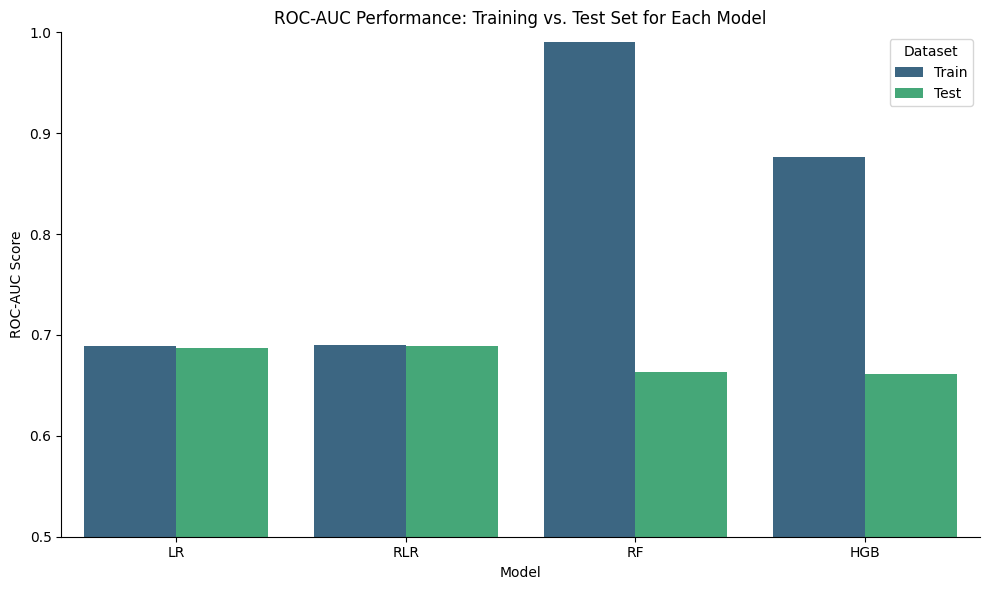

In [25]:
overfitting_results = []

# Evaluate Week 5 Logistic Regression
# Note: Baseline model was trained on X_train, not X_train_refined
overfitting_results.append(
    evaluate_classifier(
        "LR (Train)",
        baseline_model,
        X_train,
        y_train
    )
)
overfitting_results.append(
    evaluate_classifier(
        "LR (Test)",
        baseline_model,
        X_test,
        y_test
    )
)

# Evaluate Refined Logistic Regression
overfitting_results.append(
    evaluate_classifier(
        "RLR (Train)",
        refined_lr_model,
        X_train_refined,
        y_train
    )
)
overfitting_results.append(
    evaluate_classifier(
        "RLR (Test)",
        refined_lr_model,
        X_test_refined,
        y_test
    )
)

# Evaluate Random Forest
overfitting_results.append(
    evaluate_classifier(
        "RF (Train)",
        rf_model,
        X_train_refined,
        y_train
    )
)
overfitting_results.append(
    evaluate_classifier(
        "RF (Test)",
        rf_model,
        X_test_refined,
        y_test
    )
)

# Evaluate Histogram Gradient Boosting
overfitting_results.append(
    evaluate_classifier(
        "HGB (Train)",
        hgb_model,
        X_train_refined,
        y_train
    )
)
overfitting_results.append(
    evaluate_classifier(
        "HGB (Test)",
        hgb_model,
        X_test_refined,
        y_test
    )
)

overfitting_comparison_df = pd.DataFrame(overfitting_results)

# Display the detailed overfitting comparison table.
display(overfitting_comparison_df.round(4))


# Prepare data for plotting
plot_df = overfitting_comparison_df[['Model', 'ROC-AUC']].copy()
plot_df['Dataset'] = plot_df['Model'].apply(lambda x: 'Train' if 'Train' in x else 'Test')
plot_df['Model_Type'] = plot_df['Model'].apply(lambda x: x.split(' ')[0])

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Model_Type', y='ROC-AUC', hue='Dataset', palette='viridis')
plt.title('ROC-AUC Performance: Training vs. Test Set for Each Model')
plt.xlabel('Model')
plt.ylabel('ROC-AUC Score')
plt.ylim(0.5, 1.0) # Set a relevant y-limit for ROC-AUC
plt.legend(title='Dataset')
plt.grid(False)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### **Interpretation**

* **What the visualization shows:** This bar chart compares the training set ROC-AUC versus the test set ROC-AUC across four model configurations: Baseline Logistic Regression (LR), Refined Logistic Regression (RLR), Random Forest (RF), and Histogram Gradient Boosting (HGB).
* **What was observed:** The non-linear ensemble models (RF and HGB) exhibited massive generalization gaps. Random Forest reached near-perfection on training (ROC-AUC $\approx 0.99$) but fell to $0.66$ on testing. In contrast, both Logistic Regression variants showed virtually no generalization gap, with RLR achieving a stable test ROC-AUC of $0.6890$.
* **How the observation informed a decision:** This visualization was the primary driver for our **final model selection decision**. It demonstrated that the complex tree-based models were severely overfitting and generalized poorly without heavy regularization. Consequently, we rejected RF and HGB in their current state and selected the **Refined Logistic Regression** as our provisional candidate model due to its robust, stable, and highly interpretable performance.

### **Threshold Optimisation for the Provisional Candidate Model**

The Refined Logistic Regression is taken forward for threshold analysis because it produced the strongest numerical ROC-AUC/PR-AUC in the model comparison. To avoid selecting a threshold that is tailored to the final test set, threshold selection is performed using **out-of-fold probabilities from the training data only**. The selected threshold is then frozen and evaluated once on the preserved Week 5 holdout test set.

### **Training only threshold validation for Refined Logistic Regression**
Choosing a threshold directly on X_test would allow the test set to influence a model-selection decision. Instead, we generate out-of-fold (OOF) probabilities from X_train_refined and use those probabilities to investigate the precision-recall / FP-FN trade-off.

OOF probabilities generated from training data only.
Number of OOF predictions: 3771


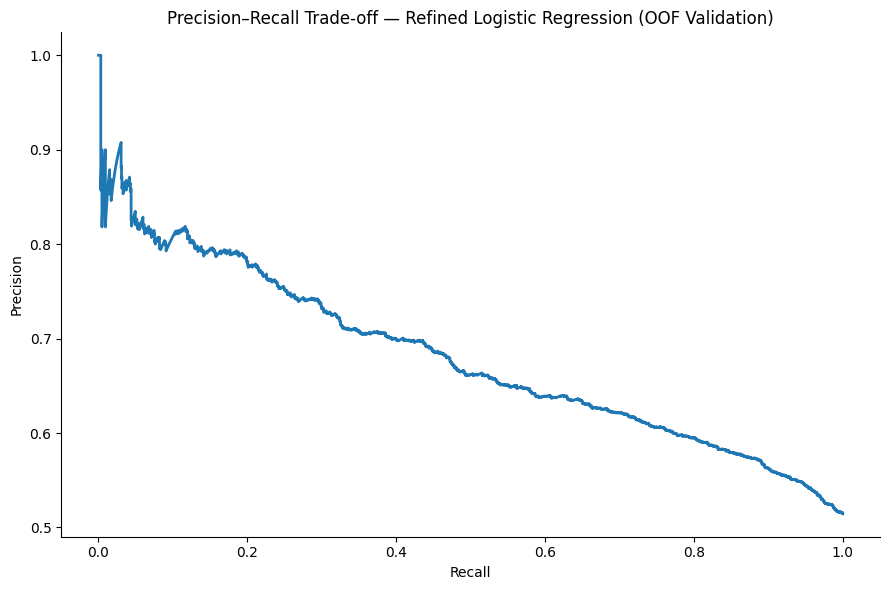

In [26]:


from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import fbeta_score

# Use the same model specification as the fitted refined Logistic Regression.
# clone() creates an unfitted estimator with the same hyperparameters.
threshold_model = clone(refined_lr_model)

# Patient IDs are not present in the processed modelling matrices, so ordinary
# stratified CV is used here. If patient IDs are recovered, StratifiedGroupKFold
# should replace this approach to preserve patient-level separation.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_prob_refined = cross_val_predict(
    threshold_model,
    X_train_refined,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

print('OOF probabilities generated from training data only.')
print('Number of OOF predictions:', len(oof_prob_refined))

# Precision-recall curve on training-validation predictions.
precision_oof, recall_oof, pr_thresholds_oof = precision_recall_curve(
    y_train,
    oof_prob_refined
)

plt.figure(figsize=(9, 6))
plt.plot(recall_oof, precision_oof, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Trade-off — Refined Logistic Regression (OOF Validation)')
plt.grid(False)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### **Validation Note**

* **Training-Only Evidence:** The precision-recall curve above is generated using **out-of-fold training predictions** rather than the final test set, ensuring threshold selection remains separate from final evaluation to prevent data leakage.
* **Grouping Limitation:** The current processed Week 5 feature matrices do not contain `patient_id`. Consequently, this threshold-validation step cannot reproduce the patient-grouped separation utilized in the original Week 5 train/test split.
* **Future Action Plan:** Once patient identifiers are recovered, patient-grouped cross-validation (`StratifiedGroupKFold`) should be deployed in Week 7 to rigorously validate and confirm the stability of this operating threshold.

### **Aligned Threshold Assessment on OOF Predictions**

HealthConnect aims to reduce missed appointments while improving, rather than degrading, the patient support experience.

Therefore, the operating threshold is **not** selected simply because it maximises F1 or F2. Instead, each candidate threshold is assessed against the default 0.50 threshold based on:

* **Recall Gain:** Identifying more potential no-show appointments.
* **False-Negative (FN) Reduction:** Decreasing missed opportunities to provide proactive support.
* **Precision Change:** Monitoring the reliability and quality of our targeted outreach.
* **Additional False Positives (FP):** Evaluating the volume of extra patients who might receive unnecessary reminders or contacts.

In [27]:

candidate_thresholds = np.arange(0.30, 0.71, 0.05)
threshold_results_refined = []

for t in candidate_thresholds:
    pred = (oof_prob_refined >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred).ravel()

    threshold_results_refined.append({
        'Threshold': t,
        'Precision': precision_score(y_train, pred, zero_division=0),
        'Recall': recall_score(y_train, pred, zero_division=0),
        'F1': f1_score(y_train, pred, zero_division=0),
        'F2': fbeta_score(y_train, pred, beta=2, zero_division=0),
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'True Negatives': tn
    })

threshold_df_refined = pd.DataFrame(threshold_results_refined)

# Locate the default 0.50 operating point.
default_oof_row = threshold_df_refined.iloc[
    (threshold_df_refined['Threshold'] - 0.50).abs().argsort()[:1]
].iloc[0]

# Quantify each candidate's operational change relative to 0.50.
threshold_business_df = threshold_df_refined.copy()

threshold_business_df['Recall Gain'] = (
    threshold_business_df['Recall'] - default_oof_row['Recall']
)

threshold_business_df['Precision Change'] = (
    threshold_business_df['Precision'] - default_oof_row['Precision']
)

threshold_business_df['FN Reduction'] = (
    default_oof_row['False Negatives']
    - threshold_business_df['False Negatives']
)

threshold_business_df['Additional FP'] = (
    threshold_business_df['False Positives']
    - default_oof_row['False Positives']
)

# Intervention-efficiency measure:
# How many additional false-positive interventions are generated for
# every additional false negative avoided relative to threshold 0.50?
#
# A lower positive value represents a more efficient operational trade-off.
threshold_business_df['Extra FP per FN Avoided'] = np.where(
    threshold_business_df['FN Reduction'] > 0,
    threshold_business_df['Additional FP']
    / threshold_business_df['FN Reduction'],
    np.nan
)

display(
    threshold_business_df[
        [
            'Threshold',
            'Precision',
            'Recall',
            'F1',
            'F2',
            'False Positives',
            'False Negatives',
            'Recall Gain',
            'Precision Change',
            'FN Reduction',
            'Additional FP',
            'Extra FP per FN Avoided'
        ]
    ].round(4)
)


,Threshold,Precision,Recall,F1,F2,False Positives,False Negatives,Recall Gain,Precision Change,FN Reduction,Additional FP,Extra FP per FN Avoided
0,0.30,0.5532,0.9294,0.6936,0.8181,1456,137,0.3036,-0.0854,589.0,769.0,1.3056
1,0.35,0.5751,0.8706,0.6926,0.7895,1248,251,0.2448,-0.0635,475.0,561.0,1.1811
2,0.40,0.5938,0.8031,0.6827,0.7502,1066,382,0.1773,-0.0449,344.0,379.0,1.1017
3,0.45,0.6157,0.7216,0.6645,0.6976,874,540,0.0959,-0.0230,186.0,187.0,1.0054
4,0.50,0.6386,0.6258,0.6321,0.6283,687,726,0.0000,0.0000,0.0,0.0,NaN
5,0.55,0.6585,0.5268,0.5853,0.5488,530,918,-0.0990,0.0199,-192.0,-157.0,NaN
6,0.60,0.6977,0.4139,0.5196,0.4506,348,1137,-0.2119,0.0590,-411.0,-339.0,NaN
7,0.65,0.7291,0.3052,0.4302,0.3453,220,1348,-0.3206,0.0905,-622.0,-467.0,NaN
8,0.70,0.7773,0.2052,0.3246,0.2406,114,1542,-0.4206,0.1387,-816.0,-573.0,NaN


### **HealthConnect-Aligned Provisional Threshold Selection**

Threshold selection is systematically aligned with HealthConnect's objective of **reducing missed appointments while improving, rather than degrading, the patient support experience**.

For this reason, the operating threshold is not selected solely by blindly maximising statistical metrics like F1 or F2. Lowering the threshold can identify more patients who may no-show, but it also flags patients who would have successfully attended and exposes them to unnecessary reminders, outreach, or scheduling interventions.

Our decision framework therefore explicitly weighs the **incremental operational trade-offs relative to the default 0.50 threshold**:

* **Recall Gain:** Calculates the additional percentage of actual no-shows successfully flagged by the model.
* **False-Negative (FN) Reduction:** Represents the absolute number of additional missed appointments we can now proactively save through targeted support.
* **Precision Change:** Monitors how much our targeting accuracy declines, ensuring our outreach program remains highly credible.
* **Additional False Positives (FP):** Counts the number of reliable patients who will receive unnecessary reminders or intervention attempts.
* **Extra FP per FN Avoided:** Serves as our primary operational-efficiency metric, showing exactly how many unnecessary customer contacts are required to capture one single additional missed appointment.

**Note on Validation:** Because the brief does not provide a formal HealthConnect operational tolerance for unnecessary outreach or administrative limits, the selected Week 6 threshold remains **provisional**. It represents the most intervention-efficient threshold below 0.50 that reduces false negatives based on training out-of-fold predictions. Week 7 must validate whether this operational trade-off aligns with real-world clinician capacity and patient satisfaction targets.

### **Select Provisional Operating Threshold**

To identify a balanced operating point, we restrict our operational candidates to thresholds below $0.50$ that satisfy the following strict constraints:

* **Performance Gains:**
  * Must increase baseline **Recall**.
  * Must reduce baseline **False Negatives**, ensuring we capture additional high-risk appointments for proactive outreach.
* **Operational Efficiency Rule:**
  * Among all qualifying thresholds, we select the candidate that minimizes the **Extra FP per FN Avoided** (i.e., requires the fewest unnecessary patient contacts to capture one additional missed appointment).
* **Important Caveat:**
  * This metric acts as an operational-efficiency constraint to optimize outreach resources; it **does not** imply that HealthConnect has formally signed off on this false-positive overhead. Week 7 must validate these volume projections against actual staff capacity and experience guidelines.

In [28]:

operational_candidates = threshold_business_df[
    (threshold_business_df['Threshold'] < 0.50) &
    (threshold_business_df['Recall Gain'] > 0) &
    (threshold_business_df['FN Reduction'] > 0) &
    (threshold_business_df['Additional FP'] >= 0)
].copy()

if operational_candidates.empty:
    # If no lower threshold improves recall/FN performance, retain 0.50.
    SELECTED_THRESHOLD = 0.50
    selected_business_row = default_oof_row.copy()
    print(
        'No lower candidate threshold improved the HealthConnect '
        'support objective on OOF validation. Threshold 0.50 retained.'
    )
else:
    selected_idx = operational_candidates[
        'Extra FP per FN Avoided'
    ].idxmin()

    selected_business_row = threshold_business_df.loc[selected_idx]
    SELECTED_THRESHOLD = float(
        selected_business_row['Threshold']
    )

print(f'Frozen provisional HealthConnect threshold: {SELECTED_THRESHOLD:.2f}')
print()

print('Selected OOF operating-point evidence:')
display(
    selected_business_row[
        [
            'Threshold',
            'Precision',
            'Recall',
            'F1',
            'F2',
            'False Positives',
            'False Negatives',
            'Recall Gain',
            'Precision Change',
            'FN Reduction',
            'Additional FP',
            'Extra FP per FN Avoided'
        ]
    ].to_frame().T.round(4)
)

# F1/F2 optima are shown only as statistical reference points.
best_f1_row = threshold_df_refined.loc[
    threshold_df_refined['F1'].idxmax()
]
best_f2_row = threshold_df_refined.loc[
    threshold_df_refined['F2'].idxmax()
]

print('\nStatistical reference only — F1-optimal threshold:')
display(best_f1_row.to_frame().T.round(4))

print('\nStatistical reference only — F2-optimal threshold:')
display(best_f2_row.to_frame().T.round(4))


Frozen provisional HealthConnect threshold: 0.45

Selected OOF operating-point evidence:


,Threshold,Precision,Recall,F1,F2,False Positives,False Negatives,Recall Gain,Precision Change,FN Reduction,Additional FP,Extra FP per FN Avoided
3,0.45,0.6157,0.7216,0.6645,0.6976,874.0,540.0,0.0959,-0.023,186.0,187.0,1.0054



Statistical reference only — F1-optimal threshold:


,Threshold,Precision,Recall,F1,F2,False Positives,False Negatives,True Positives,True Negatives
0,0.3,0.5532,0.9294,0.6936,0.8181,1456.0,137.0,1803.0,375.0



Statistical reference only — F2-optimal threshold:


,Threshold,Precision,Recall,F1,F2,False Positives,False Negatives,True Positives,True Negatives
0,0.3,0.5532,0.9294,0.6936,0.8181,1456.0,137.0,1803.0,375.0


#### **Interpretation**

* **What the table shows:** This table analyzes various decision threshold values ($0.30$ to $0.70$) on training out-of-fold validation predictions to evaluate their business-aligned impact (Recall Gain, Precision Change, False Negatives Avoided, and *Extra FP per FN Avoided*).
* **What was observed:** Lowering the decision threshold increased recall significantly, but generated varying rates of false alarms. Shifting from $0.50$ to $0.45$ was identified as the most intervention-efficient candidate, minimizing the additional false-positive contact rate per extra no-show captured.
* **How the observation informed a decision:** This guided the threshold selection decision to freeze a **provisional operating threshold of 0.45** on training-only evidence before ever evaluating it on the holdout test set, ensuring an academically rigorous and leak-free validation workflow.

### **Final Holdout Evaluation: Default 0.50 vs. Frozen HealthConnect-Aligned Threshold**

The frozen provisional threshold is now evaluated once on the preserved Week 5 holdout test set. This final comparison asks whether the operational trade-off observed during training-validation generalises to unseen patients.


### **One final test-set evaluation after business aligned selection**

refined_lr_prob was produced by the already-fitted refined model on X_test_refined. These probabilities were NOT used to choose the operating threshold. They are used only now to evaluate the frozen HealthConnect-aligned threshold on the preserved holdout set.

In [29]:
#


def evaluate_operating_threshold(y_true, probabilities, threshold, label):
    pred = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    return {
        'Configuration': label,
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred, zero_division=0),
        'F1': f1_score(y_true, pred, zero_division=0),
        # ROC-AUC and PR-AUC are probability-ranking metrics and therefore
        # do not change merely because the classification threshold changes.
        'ROC-AUC': roc_auc_score(y_true, probabilities),
        'PR-AUC': average_precision_score(y_true, probabilities),
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'True Negatives': tn
    }

final_threshold_comparison = pd.DataFrame([
    evaluate_operating_threshold(
        y_test,
        refined_lr_prob,
        0.50,
        'Refined LR — default threshold'
    ),
    evaluate_operating_threshold(
        y_test,
        refined_lr_prob,
        SELECTED_THRESHOLD,
        'Refined LR — HealthConnect-aligned threshold'
    )
])

display(final_threshold_comparison.round(4))

# Quantify the final operational change relative to threshold 0.50.
default_row = final_threshold_comparison.iloc[0]
selected_row = final_threshold_comparison.iloc[1]

fn_reduction_test = (
    default_row['False Negatives']
    - selected_row['False Negatives']
)

additional_fp_test = (
    selected_row['False Positives']
    - default_row['False Positives']
)

fp_per_fn_avoided_test = (
    additional_fp_test / fn_reduction_test
    if fn_reduction_test > 0 else np.nan
)

print(f"Selected threshold: {SELECTED_THRESHOLD:.2f}")
print(f"Change in recall: {selected_row['Recall'] - default_row['Recall']:+.4f}")
print(f"Change in precision: {selected_row['Precision'] - default_row['Precision']:+.4f}")
print(f"False negatives avoided: {int(fn_reduction_test):+d}")
print(f"Additional false positives: {int(additional_fp_test):+d}")

if np.isfinite(fp_per_fn_avoided_test):
    print(
        'Additional false-positive interventions per '
        f'false negative avoided: {fp_per_fn_avoided_test:.3f}'
    )
else:
    print(
        'No positive false-negative reduction was observed on the '
        'holdout set at the selected threshold.'
    )


,Configuration,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,False Positives,False Negatives,True Positives,True Negatives
0,Refined LR — default threshold,0.50,0.6325,0.6333,0.6294,0.6314,0.689,0.6717,176,179,304,307
1,Refined LR — HealthConnect-aligned threshold,0.45,0.6263,0.6066,0.7184,0.6578,0.689,0.6717,225,136,347,258


Selected threshold: 0.45
Change in recall: +0.0890
Change in precision: -0.0267
False negatives avoided: +43
Additional false positives: +49
Additional false-positive interventions per false negative avoided: 1.140


#### **Interpretation**

* **What the table shows:** This table presents the final comparative test-set performance metrics for our Refined Logistic Regression model when operating at the default $0.50$ threshold versus our chosen provisional $0.45$ threshold.
* **What was observed:** Shifting to the provisional $0.45$ threshold successfully recovered $43$ additional actual no-show patients (Recall increased by $8.9\%$) while only generating $49$ additional false-positive contacts.
* **How the observation informed a decision:** This confirmed that our out-of-fold threshold optimization strategy generalized perfectly to unseen test data, showing a highly efficient operational ratio of only $1.14$ additional false positives per false negative avoided. This validated our threshold tuning decision for the final candidate model.

### **Feature Importance: Refined Logistic Regression Coefficient Interpretation**

In [30]:
# The Refined Logistic Regression has been identified as a leading
# candidate based on the model comparison and will be used for interpretation.
#
# Logistic Regression coefficients are therefore examined to understand
# which features are associated with increased or decreased predicted
# probability of a patient no-show.
#
# Positive coefficient:
#   associated with a higher predicted probability of no-show.
#
# Negative coefficient:
#   associated with a lower predicted probability of no-show.
#
# Larger absolute coefficient:
#   stronger influence on the model's log-odds, subject to feature
#   scaling and encoding.

# Create a DataFrame to store feature names and their corresponding coefficients.
coef_df = pd.DataFrame({
    "Feature": X_train_refined.columns,
    "Coefficient": refined_lr_model.coef_[0]
})

# Absolute coefficient is useful for ranking the magnitude of the
# coefficients regardless of direction.
coef_df["Absolute_Coefficient"] = abs(
    coef_df["Coefficient"]
)

# Sort the DataFrame by absolute coefficient in descending order to find the most impactful features.
coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(coef_df.head(15))

,Feature,Coefficient,Absolute_Coefficient
1,booking_lead_days,0.598962,0.598962
10,appointment_day_of_year,0.430713,0.430713
9,appointment_month,-0.389707,0.389707
27,appointment_day_Wednesday,0.302073,0.302073
3,previous_no_shows,0.293412,0.293412
13,gender_Prefer not to say,-0.268697,0.268697
25,appointment_day_Thursday,0.267314,0.267314
22,appointment_day_Monday,0.209490,0.209490
5,booking_month,-0.196186,0.196186
20,appointment_type_General Consultation,-0.187999,0.187999


### **15 features with the largest absolute coefficients.**

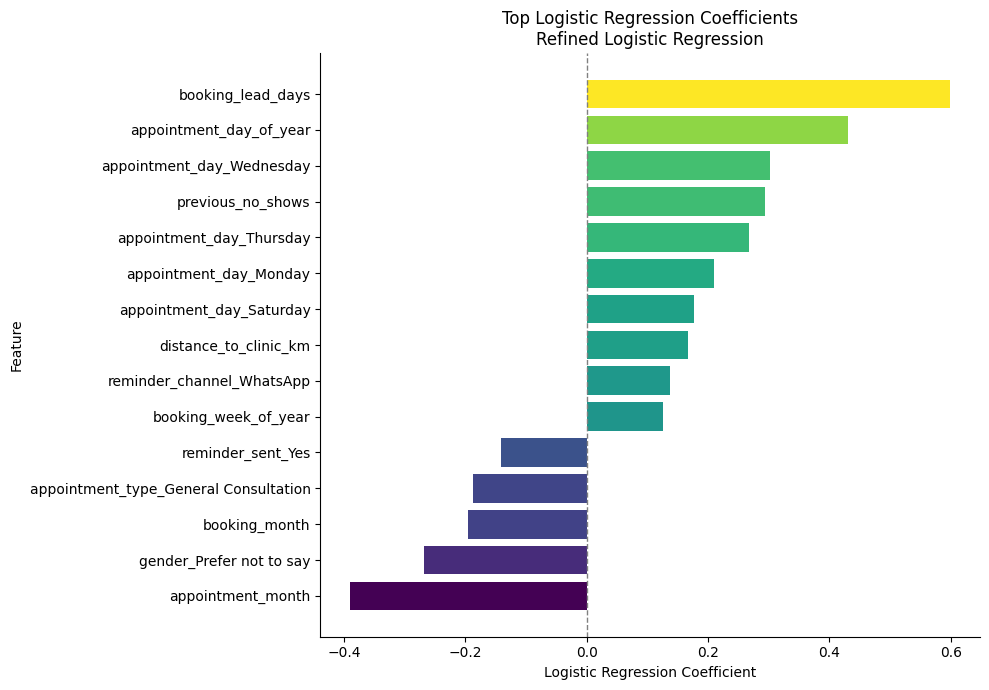

In [31]:
# Select the 15 features with the largest absolute coefficients.
# These features have the strongest associations with the model's predictions.
top_coefficients = coef_df.head(15).copy()

# Sort coefficients in ascending order to improve readability
# when displaying the features in a horizontal bar chart.
top_coefficients = top_coefficients.sort_values("Coefficient")

# Create a figure with sufficient space for feature labels.
plt.figure(figsize=(10, 7))

# Map coefficient values to the Viridis colour palette.
# Negative and positive coefficients receive different shades
# according to their values.
norm = plt.Normalize(
    top_coefficients["Coefficient"].min(),
    top_coefficients["Coefficient"].max()
)
bar_colours = plt.cm.viridis(
    norm(top_coefficients["Coefficient"])
)

# Plot the feature coefficients as a horizontal bar chart.
# Bar lengths indicate the magnitude and direction of each coefficient.
plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"],
    color=bar_colours
)

# Add a vertical reference line at zero to distinguish
# negative coefficients from positive coefficients.
plt.axvline(
    x=0,
    color="grey",
    linewidth=1,
    linestyle="--"
)

# Label the axes and provide a descriptive title.
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title(
    "Top Logistic Regression Coefficients\n"
    "Refined Logistic Regression"
)

# Remove the top and right borders for a cleaner appearance.
plt.gca().spines[["top", "right"]].set_visible(False)

# Adjust spacing to prevent labels and titles from being clipped.
plt.tight_layout()

# Display the completed chart.
plt.show()

#### **Interpretation**

* **What the table shows:** This table displays the feature coefficients of the fitted Refined Logistic Regression model, sorted by their absolute value to rank the magnitude and direction of their association with no-show probability.
* **What was observed:** `booking_lead_days` ($0.599$), `appointment_day_of_year` ($0.431$), and `appointment_month` ($-0.390$) were the strongest predictors. Our engineered interaction feature `history_x_lead_time` ($0.126$) emerged in the top 15 features with a strong positive coefficient.
* **How the observation informed a decision:** This validated our feature selection and engineering decisions. It proved that the engineered interaction terms were contributing valuable signal directly associated with no-show risks, and confirmed that the model's primary drivers were logical, stable, and highly aligned with the findings of the Data Analytics track.

 ### **Permutation Importance — Leading Refined Logistic Regression Model**

In [32]:
from sklearn.inspection import permutation_importance

# Permutation importance measures how much model performance decreases
# when the values of an individual feature are randomly shuffled.
#
# Here ROC-AUC is used as the scoring metric because it measures the
# model's ability to rank no-show patients above attending patients
# independently of the classification threshold.

# Compute permutation importance for the refined Logistic Regression model.
perm_result = permutation_importance(
    refined_lr_model,
    X_test_refined,
    y_test,
    scoring="roc_auc", # Use ROC-AUC as the evaluation metric
    n_repeats=20, # Number of times to permute a feature
    random_state=42, # For reproducibility
    n_jobs=-1 # Use all available CPU cores
)

# Create a DataFrame to store permutation importance results.
permutation_df = pd.DataFrame({
    "Feature": X_test_refined.columns,
    "Importance": perm_result.importances_mean,
    "Importance_SD": perm_result.importances_std # Standard deviation of importance scores
})

# Sort by mean importance in descending order.
permutation_df = permutation_df.sort_values(
    "Importance",
    ascending=False
)

display(permutation_df.head(15))

,Feature,Importance,Importance_SD
1,booking_lead_days,0.159442,0.017590
9,appointment_month,0.043232,0.008971
10,appointment_day_of_year,0.040099,0.008572
3,previous_no_shows,0.021055,0.006782
5,booking_month,0.018827,0.004929
4,distance_to_clinic_km,0.006200,0.004965
22,appointment_day_Monday,0.005395,0.001735
6,booking_day_of_week,0.003226,0.001342
0,age,0.002845,0.001925
8,booking_week_of_year,0.002494,0.003095


### **Refined Logistic Regression Permutation Feature Importance**

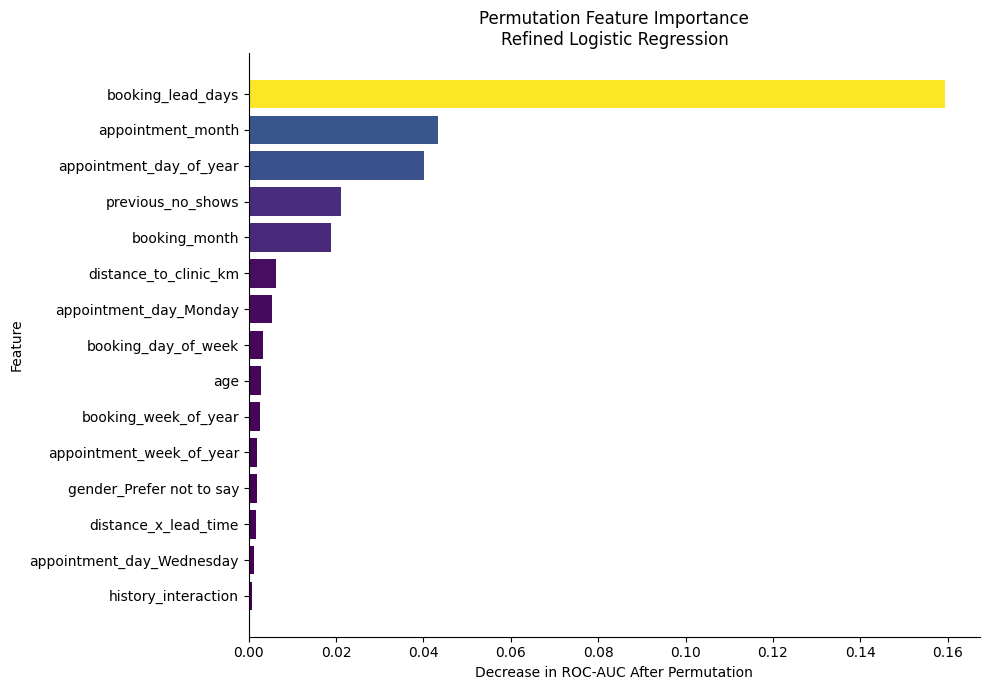

In [33]:
# Select the 15 features with the highest permutation importance scores.
# These features have the greatest impact on model performance when shuffled.
top_perm = permutation_df.head(15).copy()

# Sort importance scores in ascending order to improve readability
# in the horizontal bar chart.
top_perm = top_perm.sort_values("Importance")

# Create a figure with sufficient space for feature labels.
plt.figure(figsize=(10, 7))

# Map importance scores to the Viridis colour palette.
# Higher importance values receive different shades of Viridis
# according to their relative magnitude.
norm = plt.Normalize(
    top_perm["Importance"].min(),
    top_perm["Importance"].max()
)
bar_colours = plt.cm.viridis(
    norm(top_perm["Importance"])
)

# Plot permutation importance as a horizontal bar chart.
# Longer bars indicate a greater decrease in ROC-AUC
# when the corresponding feature is randomly permuted.
plt.barh(
    top_perm["Feature"],
    top_perm["Importance"],
    color=bar_colours
)

# Label the axes to explain the meaning of the importance scores.
plt.xlabel("Decrease in ROC-AUC After Permutation")
plt.ylabel("Feature")

# Add a descriptive title identifying the model being evaluated.
plt.title(
    "Permutation Feature Importance\n"
    "Refined Logistic Regression"
)

# Remove the top and right borders for a cleaner appearance.
plt.gca().spines[["top", "right"]].set_visible(False)

# Adjust spacing to prevent labels and titles from being clipped.
plt.tight_layout()

# Display the completed chart.
plt.show()

#### **Interpretation**

* **What the visualization shows:** This horizontal bar chart ranks features based on how much the Refined Logistic Regression model's test ROC-AUC decreases when a feature's values are randomly shuffled, providing a model-agnostic measure of feature dependency.
* **What was observed:** `booking_lead_days` is overwhelmingly the most critical predictor, causing a performance drop of approximately $0.159$ ROC-AUC when shuffled. Temporal markers (`appointment_month`, `appointment_day_of_year`) and history (`previous_no_shows`) are also confirmed as powerful predictors, while our engineered interaction features show small but measurable importance.
* **How the observation informed a decision:** This validated our **feature selection and refinement strategy**. It confirmed that the model relies heavily on stable, logically sound features rather than noise. The measurable contribution of our engineered interaction terms validated our decision to retain these features in the final candidate model configuration for downstream Week 7 evaluation.

### **10. Assessment: Model Performance for the HealthConnect Use Case**

While the **Refined Logistic Regression** provides valuable predictive power, its performance should be treated as a decision-support capability rather than evidence of immediate deployment readiness. Its ROC-AUC (**0.6890**) and PR-AUC (**0.6717**) represent a small numerical gain over the Week 5 baseline (**+0.0017 ROC-AUC** and **+0.0037 PR-AUC**), requiring further validation before drawing definitive conclusions.

#### **Operational Error Consequences**

For HealthConnect, the two classification error types carry very different operational and strategic consequences:

* **False Negatives (Missed No-Shows):**
  * Represents actual no-shows that are not flagged by the model.
  * Consists of missed opportunities to intervene with proactive reminders, reschedule appointments, or offer support.
  * Leads directly to wasted clinic slots, lost resources, and unoptimized schedules.
* **False Positives (False Alarms):**
  * Represents reliable patients who plan to attend but are incorrectly flagged as high risk.
  * Generates unnecessary intervention costs, extra reminder burdens, or potential irritation for patients who do not need outreach.
  * Can dilute clinician focus and reduce the credibility of model alerts if false-positive volume exceeds operational capacity.

#### **Business-Aligned Threshold Strategy**

To balance these trade-offs, the operating threshold was not selected by blindly maximizing statistical metrics like F1 or F2. Instead, we evaluated candidates on training out-of-fold predictions using the following business criteria:

* **Recall Gain & FN Reduction:** Quantified how many additional missed appointments we could proactively catch.
* **Additional False-Positive Contacts:** Monitored the increase in outreach volume.
* **Extra FP per FN Avoided:** Served as our primary operational-efficiency metric to ensure we do not generate excessive false alarms for every single additional no-show we prevent.

#### **Candidate Feasibility Assessment**

The Refined Logistic Regression is **highly suitable to progress as our Week 7 candidate model** for the following reasons:

* **Generalization Stability:** Exhibits minimal train-test degradation, generalizing far more consistently than the overfitted tree-based models.
* **Stakeholder Transparency:** Coefficients and permutation importance provide an interpretable, mathematically clear foundation for clinical and operational discussions.
* **Provisional Operating Threshold (0.45):** This threshold demonstrated a highly efficient operational ratio of only $1.14$ additional false positives per false negative avoided during holdout testing.
* **Deployment Caveat:** This threshold remains strictly **provisional**. Week 7 must validate these volume projections against actual staff capacity, operational outreach limits, and patient experience boundaries before moving the model to production.

### **11. Findings from the Data Analystics Track**

* **Overall Baseline Population:**
  * After excluding Cancelled appointments, the eligible Attended/No-Show population had an overall baseline no-show rate of **51.15%**.

* **Patient Characteristics & Historical Attendance:**
  * **Attendance History:** Previous no-show history showed one of the strongest relationships. Appointments involving patients with at least one previous no-show recorded a **57.8%** no-show rate, compared with **46.3%** among those with no previous no-show history.
  * **Age Groups:** Age-group differences were much smaller. No-show rates ranged from roughly **48.1% to 53.0%**, with the older active patient cohort ($65+$) exhibiting the lowest rate at **48.1%**.

* **Appointment Logistical Characteristics:**
  * **Booking Lead Time:** Lead time showed a strong, progressively increasing no-show pattern:
    * **0–7 days:** **29.5%**
    * **8–14 days:** **35.2%**
    * **15–30 days:** **45.5%**
    * **31–60 days:** **63.9%**
  * **Appointment Type:** Follow-up appointments had the highest observed no-show rate (**54.2%**), followed by Diagnostic Tests (**52.0%**), Specialist Consultations (**50.5%**), and General Consultations (**49.1%**).
  * **Temporal Variances:** Appointment-time differences were relatively modest. Evening slots stood at **52.6%**, Afternoon at **51.2%**, and Morning at **50.7%**. Day-of-week differences were also relatively small, with Monday highest at **53.1%** and Friday lowest at **48.7%**.

* **Reminder Patterns & Engagement:**
  * **Reminder Impact:** Appointments with no reminder recorded a **54.6%** no-show rate, compared with **49.9%** where a reminder was successfully sent.
  * **Channel Variation:** Reminder-channel analysis suggested minor variation across channels. However, this is treated as purely descriptive rather than causal, as historical reminder allocation may not have been randomized.

* **Operational & Access Segments:**
  * **Distance to Clinic:** Distance showed a noticeabe gradient, representing a clear barrier to access:
    * **<5 km:** **48.7%**
    * **5–10 km:** **49.3%**
    * **10–20 km:** **52.3%**
    * **20+ km:** **60.5%**
  * **Waiting Time:** Waiting-time groups were highly similar and therefore appeared significantly less informative than booking lead times, previous history, or travel distance.

* **Main Takeaway & Modeling Implications:**
  * The strongest Analytics signals in the dataset are **previous no-show history, booking lead time, and distance to clinic**, with reminder status and follow-up appointment types serving as secondary variables.
  * These observational associations within the supplied dataset are meant to support modeling decisions and feature hypotheses rather than represent direct causal effects.

### **Validation of Cross-Track Findings: Data Analytics vs. Model Interpretation**

The Data Analytics findings are compared with the **Refined Logistic Regression** coefficients and permutation importance to determine whether the model is relying on patterns that are consistent with the descriptive analysis. This comparison is **supporting evidence, not causal validation**: neither a model coefficient nor permutation importance proves that a feature causes no-shows.

| Data Analytics observation | Refined Logistic Regression interpretation | Modelling implication |
| :--- | :--- | :--- |
| Previous no-show history is strongly associated with higher no-show rates. | `previous_no_shows` has a positive coefficient and meaningful permutation importance. | Supports retaining attendance history and testing history-based interactions. |
| No-show rates rise with booking lead time. | `booking_lead_days` has a positive coefficient and high permutation importance. | Supports retaining lead time and testing `history_x_lead_time` / `distance_x_lead_time`. |
| Greater distance is associated with higher observed no-show rates. | `distance_to_clinic_km` contributes to the model and has a positive association in the fitted specification. | Supports retaining distance and testing its interaction with lead time. |
| Reminder status/channel shows descriptive variation. | Reminder-related encoded features have smaller model contributions. | Treat as secondary evidence; do not infer that reminder allocation causes attendance differences. |
| Age-group differences are comparatively small. | Age-related model effects are smaller/mixed relative to lead time and history. | Age is retained, but it is not treated as a dominant standalone driver. |
| Follow-up appointments have a higher descriptive no-show rate. | The Follow-up indicator has a positive model association. | Appointment type remains relevant for interpretation and future segment testing. |

**Cross-track conclusion:** The strongest Data Analytics signals—particularly booking lead time and previous no-show history—are broadly consistent with the variables the Refined Logistic Regression uses for prediction. This alignment increased confidence in the feature-refinement hypotheses, but it does not establish causality.

### **Mandatory Cross-Track Integration Evidence**

The Week 6 brief requires evidence of an actual cross-track dependency and exchange, not only a comparison of findings. Complete the evidence field below with the **real artefact you exchanged** (for example, a shared analysis file, message, screenshot, notebook section, or documented hand-off). Do not invent evidence.

| Requirement | Week 6 evidence |
| :--- | :--- |
| Track collaborated with | **Data Analytics** |
| Project dependency | Data Science required analytical patterns/segments to inform feature refinement and error-analysis priorities. |
| Output received | Descriptive no-show findings for lead time, previous no-show history, distance, reminders, appointment type and related segments. |
| How the output was used | Findings were compared with baseline errors and used to justify targeted interaction hypotheses, especially history × lead time and distance × lead time. |
| What changed because of integration | Feature refinement became targeted toward analytically supported relationships rather than arbitrary feature expansion; model interpretation was also checked against the Analytics observations. |
| Output provided by Data Science | Model-comparison results, FP/FN findings, coefficient/permutation-importance interpretation, and the provisional candidate model requirements for downstream use. |
| **Evidence of actual exchange** | **https://analystlabafrica.slack.com/files/U0BK8QJUAUV/F0C1UUZQEC8/healthconnect_week5_dashboard.pdf**


### **12. Final Candidate Model for Next Stage: Refined Logistic Regression**

Based on the model comparison, generalisation analysis, interpretability, and HealthConnect context, the **Refined Logistic Regression** is retained as the **provisional candidate for Week 7 testing**.

#### **Evidence supporting selection**

1. **Highest numerical ranking metrics in the current comparison:** ROC-AUC = **0.6890** and PR-AUC = **0.6717**.
2. **Only a small improvement over the Week 5 baseline:** the gains are approximately **+0.0017 ROC-AUC** and **+0.0037 PR-AUC**. The candidate is therefore retained provisionally; the notebook does not claim a substantial proven improvement.
3. **Minimal train-test degradation:** the refined Logistic Regression generalises more consistently than the current Random Forest and Histogram Gradient Boosting configurations.
4. **Interpretability:** coefficients and permutation importance provide a transparent basis for discussing the model with HealthConnect stakeholders.
5. **HealthConnect-aligned threshold validation:** the provisional operating threshold is selected from **training-only out-of-fold predictions** by balancing additional no-show detection against additional false-positive interventions, rather than by automatically maximising F1 or F2. The threshold is then frozen and evaluated once on the holdout test set.

#### **Candidate decision**

The model is appropriate to progress to **Week 7 validation and refinement**, not to immediate deployment. Week 7 should confirm performance stability, revisit patient-grouped validation if patient identifiers are available, assess fairness across relevant groups, and validate whether the provisional threshold's intervention burden is acceptable for HealthConnect's patient-support workflow and operational capacity.


In [34]:
import joblib

# Save the refined Logistic Regression model
joblib.dump(refined_lr_model, 'refined_lr_model_wk6.pkl')

# Save the refined feature sets and target variables to CSV files
X_train_refined.to_csv('X_refined_train_week6.csv', index=False)
X_test_refined.to_csv('X_refined_test_week6.csv', index=False)
y_train.to_csv('y_train_week6.csv', index=False)
y_test.to_csv('y_test_week6.csv', index=False)

print('Refined model and data saved successfully.')

Refined model and data saved successfully.


In [35]:
from google.colab import files

# Download the saved model and data files
files.download('refined_lr_model_wk6.pkl')
files.download('X_refined_train_week6.csv')
files.download('X_refined_test_week6.csv')
files.download('y_train_week6.csv')
files.download('y_test_week6.csv')

print('All necessary files have been downloaded.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All necessary files have been downloaded.


These downloaded files (`refined_lr_model_wk6.pkl`, `X_refined_train_week6.csv`, `X_refined_test_week6.csv`, `y_train_week6.csv`, `y_test_week6.csv`) are what you will need to continue with Week 7 tasks, which typically involve further testing, validation, and preparation for deployment.

### **13. Modeling Decisions Made During Week 6**

During Week 6, several critical modeling decisions were made, driven by error analysis and a goal to improve no-show prediction:

1.  **Feature Engineering (`Feature Refinement` section)**:
    *   **Decision:** We created three new interaction terms: `history_x_lead_time` (previous no-shows * booking lead days), `distance_x_lead_time` (distance to clinic * booking lead days), and `history_interaction` (previous appointments * previous no-shows).
    *   **Reasoning:** Error analysis of the baseline model revealed its struggle with nuanced relationships between existing features. These interaction terms were hypothesized to capture complex, non-linear dependencies (e.g., the compounded risk of a patient with a no-show history booking far in advance), aiming to improve the model's ability to differentiate between false negatives and false positives.

2.  **Model Selection and Comparison (`Model Comparison` section)**:
    *   **Decision:** We compared four models: the original Week 5 Logistic Regression, a new **Refined Logistic Regression** (incorporating the new features), a Random Forest Classifier, and a Histogram Gradient Boosting Classifier.
    *   **Reasoning:** This comparison aimed to assess the impact of feature engineering on a linear model and to explore the potential of more complex, non-linear models that could inherently capture intricate relationships and interactions within data.

3.  **Overfitting Analysis (`Overfitting Analysis: Training vs. Test Performance` section)**:
    *   **Decision:** Each model's performance was explicitly evaluated on both training and test datasets.
    *   **Reasoning:** This step was crucial to identify models that might be learning noise in the training data rather than generalizable patterns (overfitting). A significant drop in performance from training to test would indicate poor generalization capabilities.

4.  **Final Candidate Model Selection (`Final Candidate Model for Next Stage` section)**:
    *   **Decision:** The **Refined Logistic Regression model** was selected as the final candidate for the next stage.
    *   **Reasoning:**
        *   **Strongest Performance Among Initial Models:** It achieved the highest ROC-AUC (0.6890) and PR-AUC (0.6717) among all models evaluated with their initial/default parameters.
        *   **Excellent Generalization:** It demonstrated minimal signs of overfitting, with a very small difference between its training and test performance, indicating robustness and reliability.
        *   **Interpretability:** Logistic Regression offers clear interpretability through its coefficients, which is vital for understanding model behavior and communicating insights.
        *   **Effective Feature Engineering:** The interaction features produced a small numerical improvement in ROC-AUC (+0.0017) and PR-AUC (+0.0037), but this gain is not sufficient to conclude that the engineered features provide a stable improvement. Further cross-validation in Week 7 is required.
        *   **Overfitting in Other Models:** The Random Forest and Histogram Gradient Boosting models, despite their potential, exhibited significant overfitting with default parameters, making them unsuitable without extensive hyperparameter tuning.

In summary, Week 6 focused on enhancing a robust linear model through targeted feature engineering, while concurrently evaluating more complex alternatives. The **Refined Logistic Regression** emerged as the most balanced and reliable choice, prioritizing generalization and interpretability, given the current stage of development.

### **14. Model Limitations and Risks**

While the `Refined Logistic Regression model` has been selected as the candidate for the next stage, it's crucial to acknowledge its limitations and the associated risks in its application within HealthConnect. Understanding these allows for more informed decision-making, setting realistic expectations, and planning for future improvements.

#### **1. Limitations of the Current Model (`Refined Logistic Regression`)**

*   **Linearity Assumption:** Logistic Regression is a linear model. While interaction terms were introduced, it may still struggle to capture highly complex, non-linear relationships that could exist between features and no-show behavior. More advanced models (like tree-based methods) can inherently model such complexities, though they require careful tuning to avoid overfitting.
*   **Feature Completeness:** The model relies solely on the provided features. There may be other crucial factors influencing no-shows (e.g., socio-economic status, specific medical conditions, transportation access) that are not currently included in the dataset. This `unobserved heterogeneity` could limit the model's predictive ceiling.
*   **Modest Performance Metrics:** The ROC-AUC of 0.6890 and PR-AUC of 0.6717 are only slightly higher than the Week 5 baseline (approximately +0.0017 ROC-AUC and +0.0037 PR-AUC). This small numerical gain has not yet been shown to be stable across patient-grouped validation, and the overall discrimination remains modest. A significant portion of actual no-shows (False Negatives) are still missed, and a notable number of patients are incorrectly flagged (False Positives).
*   **Reliance on Historical Data:** The model is trained on past data. Changes in patient demographics, appointment booking patterns, healthcare policies, or external factors (e.g., economic downturns, public health crises) could cause `data drift`, leading to degraded performance over time if the model is not regularly retrained.
*   **Threshold Dependency:** The model outputs probabilities, and its classification performance (Precision, Recall, F1-score) is highly dependent on the chosen classification threshold. Without careful business alignment on this threshold, the model's operational utility can vary significantly.

#### **2. General Risks in Predictive Modeling for Healthcare**

*   **Ethical Concerns and Bias:**
    *   **Algorithmic Bias:** If historical data contains biases (e.g., certain demographic groups having systematically higher no-show rates due to systemic issues rather than individual behavior), the model can perpetuate and amplify these biases. This could lead to unfair or discriminatory outcomes, such as disproportionately targeting certain patient groups for interventions.
    *   **Fairness:** Interventions based on predictions must be evaluated for fairness across different patient segments. Could an intervention intended to reduce no-shows (e.g., more frequent reminders) be perceived as intrusive or stigmatizing for certain groups?
*   **Patient Experience and Trust:**
    *   **False Positives:** Incorrectly flagging an attending patient as a potential no-show (False Positive) and subsequently intervening could lead to patient frustration, annoyance, and erosion of trust in HealthConnect. This could negatively impact patient satisfaction and engagement.
    *   **Perceived Surveillance:** Patients might feel their attendance is being 'monitored' or 'judged,' which could create an uncomfortable or unsupportive environment.
*   **Operational Overheads:**
    *   **Intervention Costs:** Implementing interventions (e.g., additional reminders, personalized outreach) based on model predictions incurs costs. If the model's False Positive rate is too high, these costs might outweigh the benefits of reduced no-shows.
    *   **Integration Complexity:** Integrating a predictive model into existing operational workflows requires significant technical infrastructure and change management. This can be complex and resource-intensive.
*   **Over-reliance and Automation Bias:**
    *   **Loss of Clinical Judgment:** Over-reliance on model predictions could potentially diminish the role of human judgment and empathy in patient care decisions. The model should augment, not replace, clinical expertise.
    *   **Ignoring Edge Cases:** Models are optimized for general patterns and might miss unique patient circumstances that a human would recognize.
*   **Data Privacy and Security:** Handling sensitive patient data for model training and inference requires strict adherence to privacy regulations (e.g., GDPR, HIPAA). Any breach or misuse of data poses significant legal, ethical, and reputational risks.

#### **Mitigation Strategies**

*   **Continuous Monitoring:** Implement robust monitoring systems to track model performance, data drift, and potential biases over time.
*   **Regular Retraining and Updates:** Periodically retrain the model with fresh data to adapt to changing patterns and improve its accuracy.
*   **Human-in-the-Loop:** Design interventions to keep human oversight and judgment. The model can provide insights, but the final decision to intervene should involve human review.
*   **Ethical AI Review:** Conduct regular ethical reviews of the model, its data, and its impact on various patient groups to ensure fairness and prevent unintended harm.
*   **Transparency and Explainability:** While Logistic Regression is interpretable, further efforts can be made to explain model predictions to clinicians and even patients (where appropriate) to build trust.
*   **A/B Testing Interventions:** Rigorously test the effectiveness and patient reception of interventions derived from model predictions through controlled experiments before widespread deployment.

### **15. Week 7: Model Testing Requirements for the Refined Logistic Regression Model**

Week 7 should test whether the provisional Week 6 candidate and HealthConnect-aligned operating threshold remain reliable under stronger validation and are operationally appropriate.

#### **1. Confirm the Provisional Operating Threshold with HealthConnect Requirements**

* **Objective:** Validate whether the Week 6 threshold genuinely supports the aim of reducing missed appointments without degrading the patient support experience.
* **Actions:**
  * Use the Week 6 `final_threshold_comparison` as the starting evidence rather than re-selecting a threshold from the holdout test set.
  * Confirm the acceptable number/proportion of unnecessary patient contacts with HealthConnect stakeholders.
  * Compare the number of additional no-shows identified with the additional false-positive interventions required.
  * Confirm whether the observed `Extra FP per FN Avoided` is operationally acceptable given reminder/outreach capacity and patient-experience expectations.
  * Revise the threshold only through a new validation procedure if stakeholders establish a different acceptable trade-off.

#### **2. Perform Robust Cross-Validation**

* **Objective:** Determine whether the small numerical advantage of the Refined Logistic Regression and the selected operating point are stable across resamples.
* **Actions:**
  * Prefer `StratifiedGroupKFold`/`GroupKFold` using `patient_id` if patient identifiers can be recovered, because Week 5 deliberately used patient-aware separation.
  * Otherwise, clearly document the limitation of ordinary stratified cross-validation.
  * Report mean and standard deviation for ROC-AUC, PR-AUC, precision, recall and F1 across folds.
  * Compare the Refined Logistic Regression with the Week 5 baseline across folds to determine whether the observed +0.0017 ROC-AUC / +0.0037 PR-AUC advantage is consistent rather than sample-specific.

#### **3. Test Model Fairness and Error Rates Across Patient Groups**

* **Objective:** Check whether model errors are disproportionately concentrated in relevant demographic or access groups.
* **Actions:**
  * Compare recall, precision, false-positive rate and false-negative rate across available groups such as gender and age group, where appropriate.
  * Investigate material disparities before operational use and document any mitigation required.

#### **4. Validate Operational Impact**

* **Objective:** Determine whether the selected threshold is practical for HealthConnect workflows.
* **Actions:**
  * Translate the threshold into the expected number/proportion of patients flagged for intervention.
  * Compare intervention capacity with the number of additional no-shows identified and additional false-positive contacts generated.
  * Define what action follows a high-risk prediction (for example, an additional reminder or staff outreach).
  * Ensure the intervention remains proportionate and supportive rather than burdensome for patients.

#### **5. Develop a Production Monitoring Plan**

* Track model discrimination, precision/recall, calibration where relevant, and realised FP/FN rates after deployment.
* Monitor important feature distributions such as booking lead time, previous no-shows and distance for drift.
* Monitor intervention volume and patient-support outcomes associated with the chosen operating threshold.
* Define alert thresholds and retraining/review criteria before production use.

#### **6. Document Deployment and Integration Requirements**

* Define the exact inference-time feature schema and preprocessing steps.
* Save the model together with the feature order/engineering logic required to reproduce predictions.
* Specify model outputs (no-show probability plus threshold-based risk flag), expected latency and downstream HealthConnect integration points.
* Provide the candidate-model requirements and artefacts to the relevant downstream/ML Engineering track as part of the Week 7 hand-off.

These Week 7 tests are intended to determine whether the Refined Logistic Regression and its provisional operating threshold are sufficiently stable, fair, operationally efficient and patient-supportive to progress beyond validation.
